In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns

In [3]:
df= pd.read_csv('Dataset\job_salary_prediction_dataset.csv')
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\j'
<>:1: SyntaxWarning: invalid escape sequence '\j'
C:\Users\HP\AppData\Local\Temp\ipykernel_21300\345956631.py:1: SyntaxWarning: invalid escape sequence '\j'
  df= pd.read_csv('Dataset\job_salary_prediction_dataset.csv')


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.shape

(250000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [9]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


##  Analisis Strategis & Efisiensi

   1. Hitung rata-rata gaji per tahun pengalaman (salary / experience_years) untuk setiap education_level.Level mana yang memberikan nilai ekonomi tertinggi diawal karier (0-3 tahun)?
   2. Di industri mana kepemilikan certifications memberikan kenaikan persentase gaji paling signifikan dibandingkan dengan yang tidak memilikinya?
   3. Identifikasi job_title yang memiliki skills_count di atas rata-rata tetapi memiliki salary di bawah median industri. (Indikasi underpaid).
   4. Apakah probabilitas mendapatkan remote_work meningkat seiring bertambahnya experience_years? Tunjukkan perbandingannya dalam persentase.
   5. Setelah mengontrol variabel experience_years (misal: hanya ambil yang 5-10 tahun), lokasi mana yang memberikan gaji tertinggi untuk industry Teknologi?

## Statistik & Distribusi

   1. Temukan job_title yang memiliki varians (standar deviasi) gaji paling tinggi. Mengapa posisi ini memiliki rentang gaji yang sangat lebar?
   2. Hitung kekuatan korelasi antara skills_count, experience_years, dan certifications terhadap salary. Mana yang paling dominan?
   3. Apakah perusahaan besar (Large) cenderung mensyaratkan education_level yang lebih tinggi dibandingkan perusahaan kecil (Small) untuk posisi yang sama?
   4. Buatlah pengelompokan (binning) gaji menjadi (Low, Medium, High) dan analisis bagaimana distribusi skills_count di masing-masing kelompok tersebut.
   5. Di setiap location, tentukan industry apa yang paling mendominasi pasar tenaga kerja dan berapa rata-rata gaji di sana.

## Prediksi & Pola Karier

   1. Pada experience_years ke berapa biasanya terjadi lonjakan gaji terbesar (salary jump) secara rata-rata di seluruh industri?
   2. Apakah karyawan di kota-kota pusat bisnis memiliki skills_count yang lebih tinggi dibandingkan daerah lain untuk job_title yang identik?
   3. Bandingkan salary karyawan remote_work dengan on-site pada company_size yang sama. Apakah remote work cenderung dibayar lebih rendah atau lebih tinggi?
   4. Cari angka certifications optimal (titik jenuh) di mana penambahan sertifikasi setelah angka tersebut tidak lagi meningkatkan salary secara signifikan.
   5. Buatlah skor gabungan (Score = Experience * Skills * Certs) dan temukan 10 karyawan dengan skor tertinggi, lalu bandingkan apakah gaji mereka sudah sesuai dengan skor tersebut.

In [10]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


##  Analisis Strategis & Efisiensi

   1. Hitung rata-rata gaji per tahun pengalaman (salary / experience_years) untuk setiap education_level.Level mana yang memberikan nilai ekonomi tertinggi diawal karier (0-3 tahun)?
   2. Di industri mana kepemilikan certifications memberikan kenaikan persentase gaji paling signifikan dibandingkan dengan yang tidak memilikinya?
   3. Identifikasi job_title yang memiliki skills_count di atas rata-rata tetapi memiliki salary di bawah median industri. (Indikasi underpaid).
   4. Apakah probabilitas mendapatkan remote_work meningkat seiring bertambahnya experience_years? Tunjukkan perbandingannya dalam persentase.
   5. Setelah mengontrol variabel experience_years (misal: hanya ambil yang 5-10 tahun), lokasi mana yang memberikan gaji tertinggi untuk industry Teknologi?

C:\Users\HP\AppData\Local\Temp\ipykernel_21300\3856468377.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_educat.index, y=df_educat['mean_salary'], palette=colors_dict,legend=False)


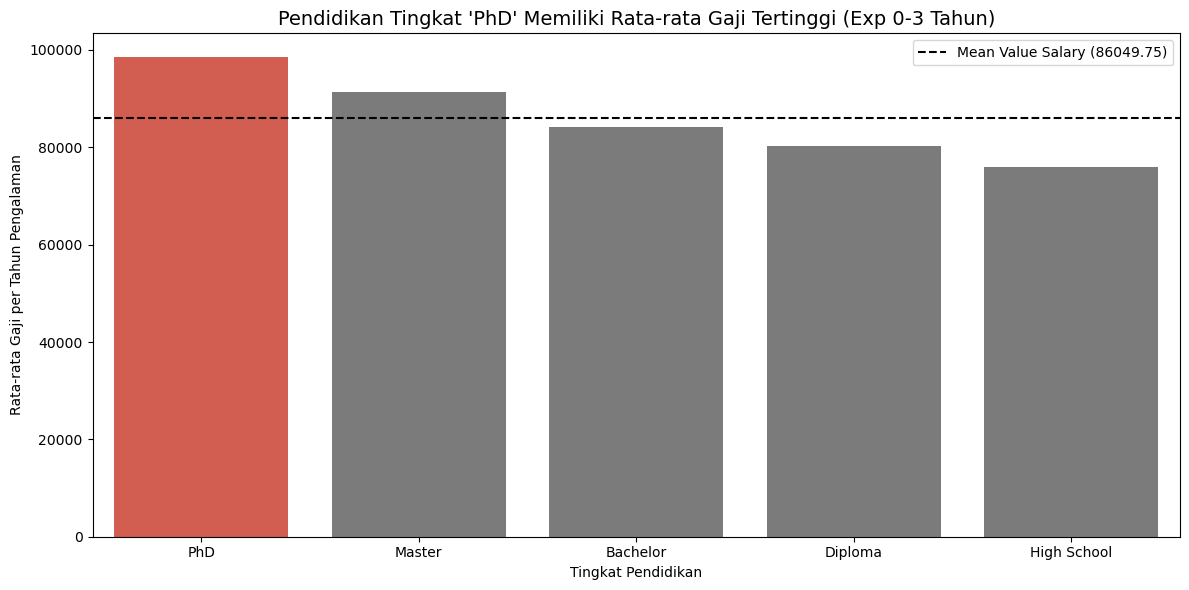

Level pendidikan dengan rata-rata gaji tertinggi adalah PhD sebesar 98493.5


In [11]:
#soal nomor 1
experience_filtered = df[(df['experience_years'] >= 0) & (df['experience_years'] <= 3)].copy()
experience_filtered['mean_salary'] = (experience_filtered['salary'] / experience_filtered['experience_years'].replace([0, 'Nan'], 1))
# Lakukan groupby menggunakan data yang sudah bersih dari NaN
df_educat = (experience_filtered.groupby('education_level')[['mean_salary', 'salary']].mean().sort_values(by='mean_salary', ascending=False).round(2))
top_edu = df_educat['mean_salary'].idxmax()
top_value = df_educat['mean_salary'].max()
meanValue = df_educat['mean_salary'].mean().round(2)

colors_dict = {x: '#e74c3c' if (x == top_edu) else "#7b7b7b" for x in df_educat.index}
# 5. Pembuatan Grafik
plt.figure(figsize=(12, 6))
sns.barplot(x=df_educat.index, y=df_educat['mean_salary'], palette=colors_dict,legend=False)
plt.axhline(meanValue, color='black', linestyle='--', label=f'Mean Value Salary ({meanValue})')
plt.title(f"Pendidikan Tingkat '{top_edu}' Memiliki Rata-rata Gaji Tertinggi (Exp 0-3 Tahun)", fontsize=14)
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Rata-rata Gaji per Tahun Pengalaman')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Level pendidikan dengan rata-rata gaji tertinggi adalah {top_edu} sebesar {top_value}")


In [12]:
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


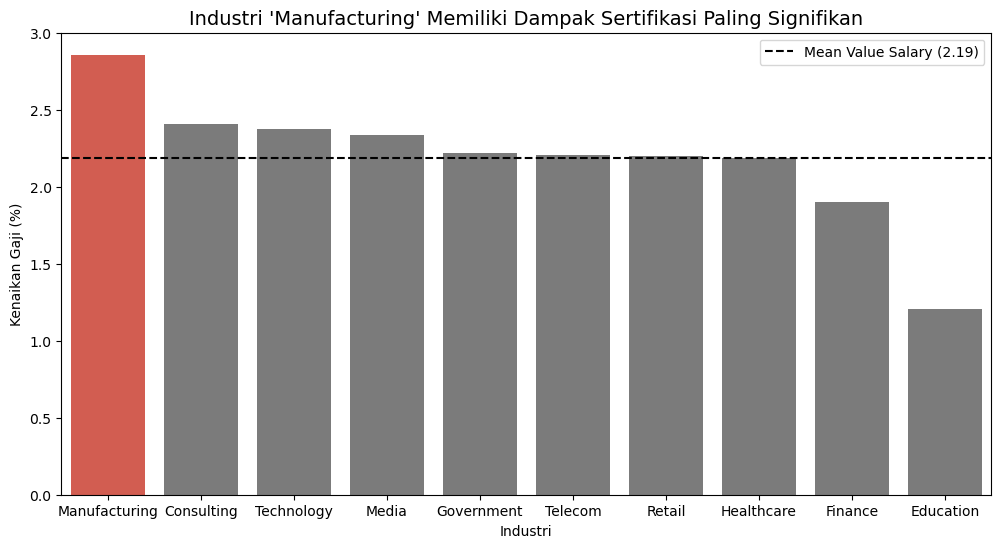

Industri dengan kenaikan persentase gaji tertinggi adalah Manufacturing sebesar 2.86%


In [13]:
#soal nomor 2
#2. Di industri mana kepemilikan certifications memberikan kenaikan persentase gaji paling signifikan dibandingkan dengan yang tidak memilikinya?
df_certif_filtered = df[df['certifications']>0]
df_noncertif_filtered = df[df['certifications'] == 1]

mean_salary_certif =df_certif_filtered.groupby('industry')['salary'].mean()
mean_salart_noncertif = df_noncertif_filtered.groupby('industry')['salary'].mean()

calcul_industry = (((mean_salary_certif-mean_salart_noncertif)/mean_salart_noncertif) * 100).sort_values(ascending=False)

top_industry = calcul_industry.idxmax()
value_industry = calcul_industry.max()
mean_value_global = calcul_industry.mean().round(2)

colors = ['#e74c3c' if (x == top_industry) else "#7b7b7b" for x in calcul_industry.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=calcul_industry.index, y=calcul_industry.round(2), palette=colors,  hue=calcul_industry.index)
plt.axhline(mean_value_global, color='black', linestyle='--', label=f'Mean Value Salary ({mean_value_global})')
plt.title(f"Industri '{top_industry}' Memiliki Dampak Sertifikasi Paling Signifikan", fontsize=14)
plt.xlabel('Industri')
plt.ylabel('Kenaikan Gaji (%)')
plt.legend()
plt.show()
print(f"Industri dengan kenaikan persentase gaji tertinggi adalah {top_industry} sebesar {value_industry:.2f}%")

In [14]:
# soal nomor 3
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


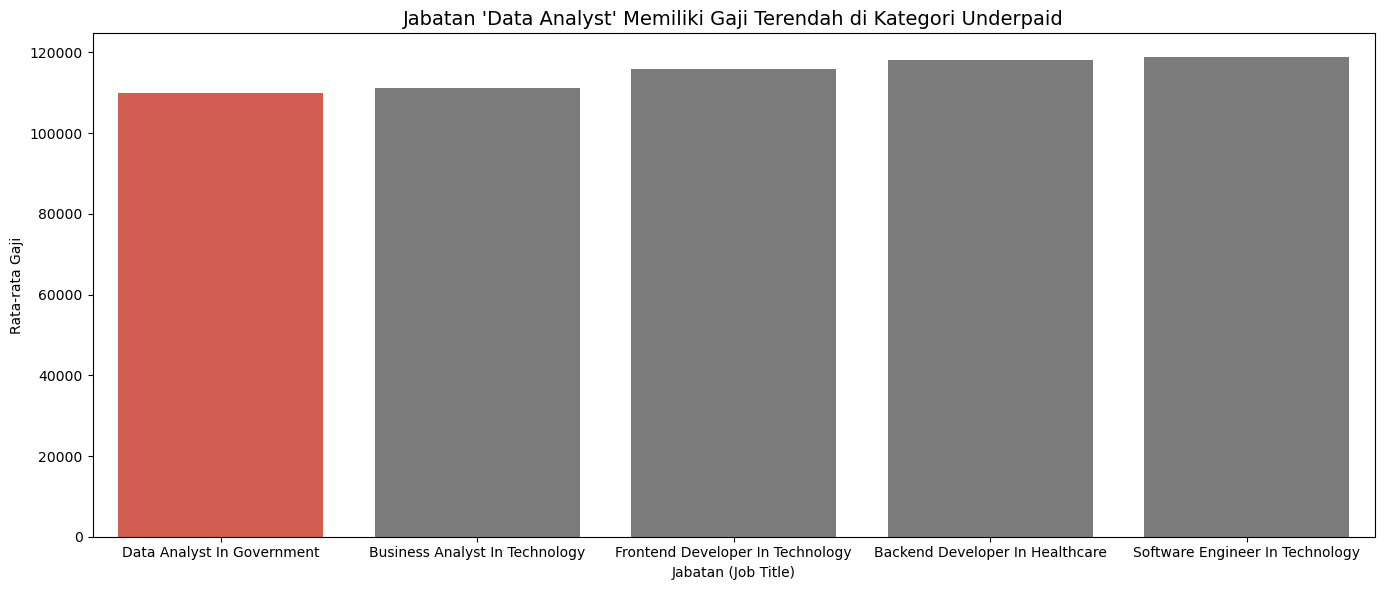

Jabatan underpaid dengan gaji terendah adalah Data Analyst In Government dengan gaji sebesar 110016.68


In [15]:
# 3. Identifikasi job_title yang memiliki skills_count di atas rata-rata tetapi memiliki salary di bawah median industri. (Indikasi underpaid).
data= df[['job_title','industry','salary','skills_count']]
avg_skill = data.groupby('job_title')['skills_count'].mean()
med_salary = data.groupby('industry')['salary'].median()
job_underpaid = data[(data['skills_count'] > data['job_title'].map(avg_skill)) & (data['salary'] < data['industry'].map(med_salary))].sort_values(by='salary',ascending=True)

topjob_underpaid = job_underpaid[['job_title', 'salary']].iloc[0]
plot_data = job_underpaid.groupby('job_title')['salary'].mean().sort_values(ascending=True).head(5)
industry_map = job_underpaid.drop_duplicates('job_title').set_index('job_title')['industry']
plot_data.index = [f"{job} In {industry_map.get(job)}" for job in plot_data.index]

global_mean_salary = plot_data.mean()
colors = ['#e74c3c' if (x == plot_data.min()) else "#7b7b7b" for x in plot_data]

plt.figure(figsize=(14, 6))
sns.barplot(x=plot_data.index, y=plot_data.values, palette=colors,hue=plot_data.index,legend=False)
plt.title(f"Jabatan '{topjob_underpaid['job_title']}' Memiliki Gaji Terendah di Kategori Underpaid", fontsize=14)
plt.xlabel('Jabatan (Job Title)')
plt.ylabel('Rata-rata Gaji')
plt.tight_layout() # Memastikan tidak ada teks yang terpotong
plt.show()
print(f"Jabatan underpaid dengan gaji terendah adalah {plot_data.index[0]} dengan gaji sebesar {plot_data.iloc[0]:.2f}")

In [16]:
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


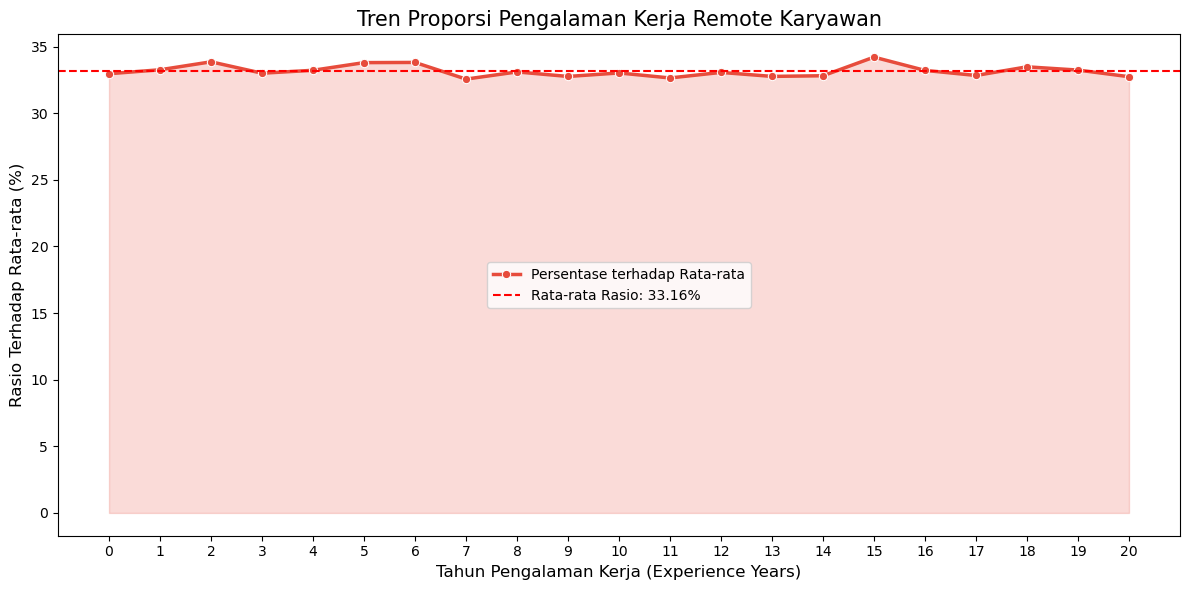

In [17]:
# soal nomor 4
# 4. Apakah probabilitas mendapatkan remote_work meningkat seiring bertambahnya experience_years? Tunjukkan perbandingannya dalam persentase.
data = df[['experience_years','remote_work']]
data_filtered = data[data['remote_work'] == 'Yes'].sort_values(by='experience_years',ascending=True)
total_perYear = data['experience_years'].value_counts()
yes_perYear = data_filtered['experience_years'].value_counts()

plot_data = (yes_perYear/total_perYear * 100).fillna(0).sort_index()
mean_line_val = plot_data.mean()
max_val = plot_data.max()
max_exp = plot_data.idxmax()

plt.figure(figsize=(12, 6))
sns.lineplot(x=plot_data.index, y=plot_data.values, marker='o', color='#e74c3c', linewidth=2.5, label='Persentase terhadap Rata-rata')
plt.fill_between(plot_data.index, plot_data.values, alpha=0.2, color='#e74c3c')
plt.axhline(mean_line_val, color='red', linestyle='--', label=f'Rata-rata Rasio: {mean_line_val:.2f}%')
plt.title('Tren Proporsi Pengalaman Kerja Remote Karyawan', fontsize=15)
plt.xlabel('Tahun Pengalaman Kerja (Experience Years)', fontsize=12)
plt.ylabel('Rasio Terhadap Rata-rata (%)', fontsize=12)
plt.xticks(plot_data.index) 
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


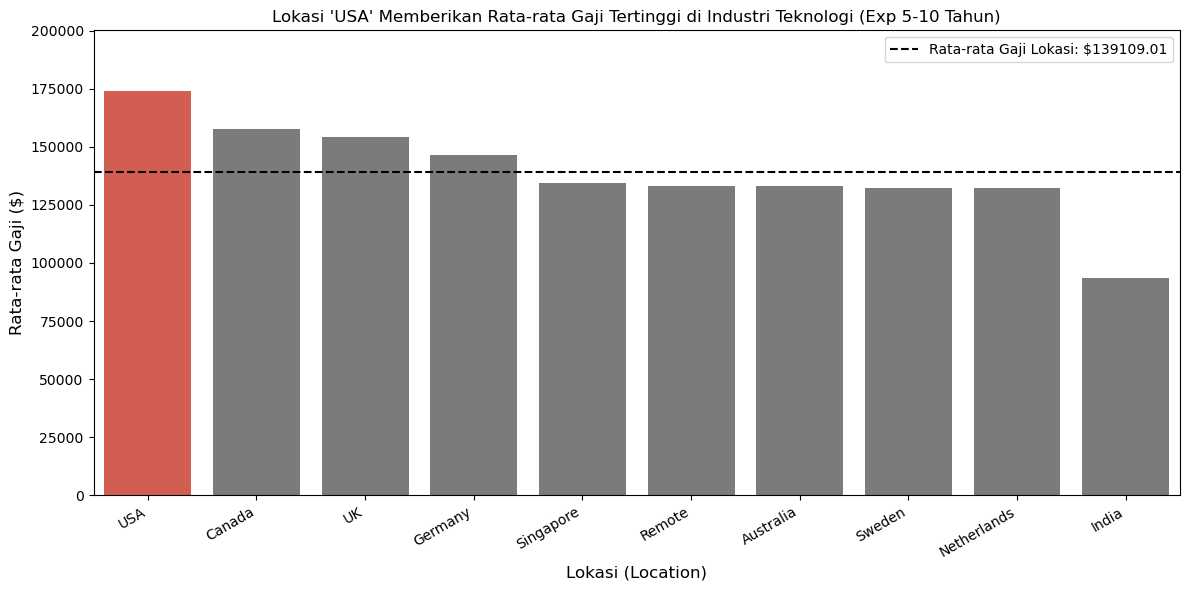

Lokasi yang memberikan gaji tertinggi dibidang Teknologi adalah : USA sebesar $174,052.38


In [19]:
#soal nomor 5
# 5. Setelah mengontrol variabel experience_years (misal: hanya ambil yang 5-10 tahun), lokasi mana yang memberikan gaji tertinggi untuk industry Teknologi?
data = df[['experience_years','location','industry','salary']].copy()
data_filtered = data[(data['industry']=='Technology') & (data['experience_years'] >= 5) & (data['experience_years'] <= 10)]
data_location = data_filtered.groupby('location')['salary'].mean().sort_values(ascending=False).round(2)

max_location = data_location.idxmax()
max_salary = data_location.max()

location_mean_salary = data_location.mean()
colors = ['#e74c3c' if (x == max_location) else "#7b7b7b" for x in data_location.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=data_location.index,  y=data_location.values,  palette=colors,  hue=data_location.index,  legend=False)
plt.axhline(location_mean_salary, color='black', linestyle='--', label=f'Rata-rata Gaji Lokasi: ${location_mean_salary:.2f}')
plt.title(f"Lokasi '{max_location}' Memberikan Rata-rata Gaji Tertinggi di Industri Teknologi (Exp 5-10 Tahun)")
plt.xlabel('Lokasi (Location)', fontsize=12)
plt.ylabel('Rata-rata Gaji ($)', fontsize=12)
plt.ylim(0, max_salary * 1.15) # Memberikan ruang di atas batang tertinggi untuk teks label
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Lokasi yang memberikan gaji tertinggi dibidang Teknologi adalah : {max_location} sebesar ${max_salary:,.2f}")


## Statistik & Distribusi

   1. Temukan job_title yang memiliki varians (standar deviasi) gaji paling tinggi. Mengapa posisi ini memiliki rentang gaji yang sangat lebar?
   2. Hitung kekuatan korelasi antara skills_count, experience_years, dan certifications terhadap salary. Mana yang paling dominan?
   3. Apakah perusahaan besar (Large) cenderung mensyaratkan education_level yang lebih tinggi dibandingkan perusahaan kecil (Small) untuk posisi yang sama?
   4. Buatlah pengelompokan (binning) gaji menjadi (Low, Medium, High) dan analisis bagaimana distribusi skills_count di masing-masing kelompok tersebut.
   5. Di setiap location, tentukan industry apa yang paling mendominasi pasar tenaga kerja dan berapa rata-rata gaji di sana.

In [20]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


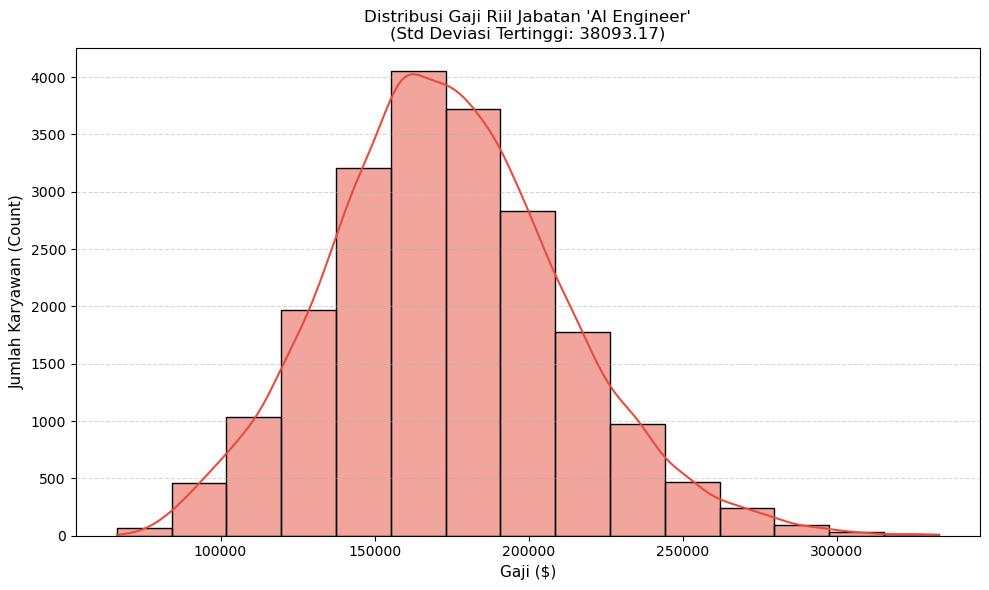

Jabatan dengan varians/standar deviasi gaji paling tinggi adalah: AI Engineer
memiliki rentang gaji yang lebar karena Nilai Standar Deviasi: 38093.17


In [21]:
#Soal nomor 1
# 1. Temukan job_title yang memiliki varians (standar deviasi) gaji paling tinggi. Mengapa posisi ini memiliki rentang gaji yang sangat lebar?
data_filtered = df[['job_title','salary']].copy()
salar_stats = data_filtered.groupby('job_title')['salary'].agg(['std']).sort_values(by='std',ascending=False)

top_job = salar_stats.index[0]
top_std = salar_stats['std'].iloc[0]
job_distribution = data_filtered[data_filtered['job_title'] == top_job]['salary']

plt.figure(figsize=(10, 6))
sns.histplot(job_distribution, kde=True, color='#e74c3c', bins=15)
plt.title(f"Distribusi Gaji Riil Jabatan '{top_job}'\n(Std Deviasi Tertinggi: {top_std:.2f})")
plt.xlabel('Gaji ($)', fontsize=11)
plt.ylabel('Jumlah Karyawan (Count)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Jabatan dengan varians/standar deviasi gaji paling tinggi adalah: {top_job}")
print(f"memiliki rentang gaji yang lebar karena Nilai Standar Deviasi: {top_std:.2f}")



In [ ]:
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


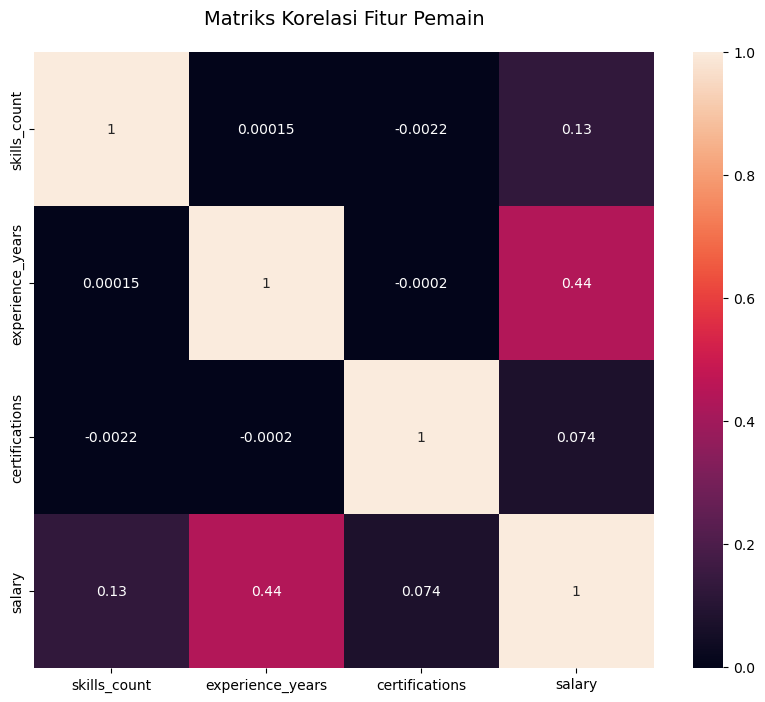

Fitur yang paling berpengaruh terhadap harga adalah: experience_years
Dengan nilai korelasi sebesar: 0.44


In [ ]:
#soal nomor 2
# 2. Hitung kekuatan korelasi antara skills_count, experience_years, dan certifications terhadap salary. Mana yang paling dominan?
data = df[['skills_count','experience_years','certifications','salary']].copy().corr()
target_cor = data['salary'].drop('salary')
fitur_terkuat = target_cor.idxmax()
fitur_value = target_cor.max()

plt.figure(figsize=(10,8))
sns.heatmap(data,annot=True)
plt.title('Matriks Korelasi Fitur Pemain',fontsize=14, pad=20)
plt.show()

print(f"Fitur yang paling berpengaruh terhadap harga adalah: {fitur_terkuat}")
print(f"Dengan nilai korelasi sebesar: {fitur_value:.2f}")

In [33]:
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


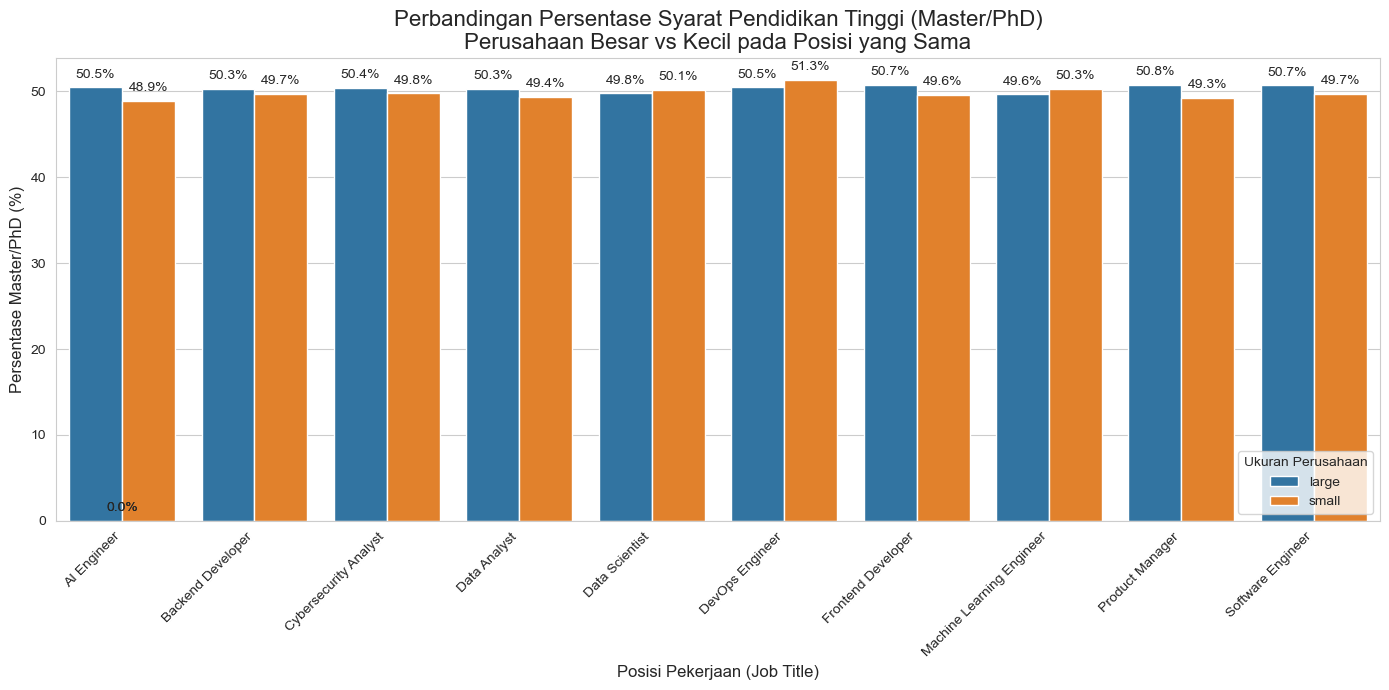

--- Persentase Pendidikan Per Posisi (Large vs Small) ---


category                     large                          small          \
education_level           Bachelor Diploma Master    PhD Bachelor Diploma   
job_title                                                                   
AI Engineer                  14.93   14.93  15.26  15.20    10.24   10.04   
Backend Developer            14.83   14.92  15.46  14.63    10.08   10.11   
Business Analyst             14.53   14.64  15.63  14.98    10.17    9.98   
Cloud Engineer               15.57   15.24  14.81  14.62     9.96    9.82   
Cybersecurity Analyst        14.87   15.01  15.11  15.25    10.00    9.98   
Data Analyst                 14.95   14.60  15.14  14.75    10.34   10.20   
Data Scientist               15.02   15.15  15.20  14.69     9.72   10.19   
DevOps Engineer              14.67   15.12  15.39  14.97     9.53    9.86   
Frontend Developer           14.75   14.67  14.99  15.31    10.08   10.22   
Machine Learning Engineer    15.04   15.06  14.89  14.77    10.21    9.81   
Product Manager              15.34   14.53  15.18  15.61     9.73   10.23   
Software Engineer            15.21   14.51  15.23  15.32    10.05    9.92   

category                                 
education_level           Master    PhD  
job_title                                
AI Engineer                 9.79   9.62  
Backend Developer          10.36   9.61  
Business Analyst            9.99  10.09  
Cloud Engineer              9.94  10.03  
Cybersecurity Analyst      10.33   9.45  
Data Analyst                9.87  10.15  
Data Scientist              9.78  10.25  
DevOps Engineer            10.06  10.40  
Frontend Developer          9.86  10.10  
Machine Learning Engineer   9.99  10.24  
Product Manager             9.66   9.72  
Software Engineer          10.26   9.49

In [ ]:
# soal nomor 3
# 3.Apakah perusahaan besar (Large) cenderung mensyaratkan education_level yang lebih tinggi dibandingkan perusahaan kecil (Small) untuk posisi yang sama?
data = df[['industry','education_level','salary','job_title']].copy()

data_indusrty = data.groupby('industry')['salary'].mean()
mean_salary_industry = data_indusrty.mean()
big_industry = data_indusrty[data_indusrty > mean_salary_industry].index
#
data['category'] = 'small'
data.loc[data['industry'].isin(big_industry),'category'] = 'large'
# #filter education level
collage = ['Bachelor', 'PhD','Diploma', 'Master']
data_filtered = data[data['education_level'].isin(collage)].copy()
# #ambil value
top_jobs = data_filtered['job_title'].value_counts().index
data_topJobs = data_filtered[data_filtered['job_title'].isin(top_jobs)]
perbandingan_posisi = (pd.crosstab(index=data_topJobs['job_title'],columns=[data_topJobs['category'],data_topJobs['education_level']],normalize='index') * 100).round(2)





# 1. Menentukan indikator "Pendidikan Lebih Tinggi" (Master & PhD)
# Kita buat kolom baru yang menandai apakah seseorang memiliki pendidikan tinggi
data_topJobs['High_Edu'] = data_topJobs['education_level'].apply(lambda x: 1 if x in ['Master', 'PhD'] else 0)

# 2. Menghitung rata-rata (persentase) pendidikan tinggi per posisi dan kategori
# Kita ambil top 10 posisi agar grafik tetap bersih
top_10_list = data_filtered['job_title'].value_counts().head(10).index
plot_data = data_topJobs[data_topJobs['job_title'].isin(top_10_list)]
plot_data = plot_data.groupby(['job_title', 'category'])['High_Edu'].mean().reset_index()
plot_data['Percentage (%)'] = plot_data['High_Edu'] * 100

# 3. Membuat Visualisasi
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=plot_data, 
    x='job_title', 
    y='Percentage (%)', 
    hue='category', 
    palette={'large': '#1f77b4', 'small': '#ff7f0e'}
)

# Menambahkan Label dan Judul
plt.title('Perbandingan Persentase Syarat Pendidikan Tinggi (Master/PhD)\nPerusahaan Besar vs Kecil pada Posisi yang Sama', fontsize=16)
plt.xlabel('Posisi Pekerjaan (Job Title)', fontsize=12)
plt.ylabel('Persentase Master/PhD (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ukuran Perusahaan')

# Menampilkan angka persentase di atas setiap batang
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=10)

plt.tight_layout()
plt.show()

print("--- Persentase Pendidikan Per Posisi (Large vs Small) ---")
perbandingan_posisi